# PGNet

![img](snippets/diagram/pgnet2.png)

install openvino dev

In [ ]:
# 安装openvino-dev
!pip install openvino==2022.3.0.dev20221125 -i https://pypi.tuna.tsinghua.edu.cn/simple

download inference model pgnet

In [11]:
!wget https://paddleocr.bj.bcebos.com/dygraph_v2.0/pgnet/e2e_server_pgnetA_infer.tar

--2023-02-01 09:01:46--  https://paddleocr.bj.bcebos.com/dygraph_v2.0/pgnet/e2e_server_pgnetA_infer.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 195768320 (187M) [application/x-tar]
Saving to: ‘e2e_server_pgnetA_infer.tar’

e2e_server_pgnetA_i 100%[===================>] 186.70M  2.98MB/s    in 63s     

2023-02-01 09:02:52 (2.98 MB/s) - ‘e2e_server_pgnetA_infer.tar’ saved [195768320/195768320]



In [13]:
!tar xvf e2e_server_pgnetA_infer.tar
!ls e2e_server_pgnetA_infer

e2e_server_pgnetA_infer/
e2e_server_pgnetA_infer/inference.pdiparams
e2e_server_pgnetA_infer/inference.pdiparams.info
e2e_server_pgnetA_infer/inference.pdmodel
inference.pdiparams  inference.pdiparams.info  inference.pdmodel


In [14]:
!git clone https://gitee.com/paddlepaddle/PaddleOCR.git

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 45329, done.
remote: Counting objects: 100% (19708/19708), done.
remote: Compressing objects: 100% (7075/7075), done.
remote: Total 45329 (delta 14389), reused 17603 (delta 12496), pack-reused 25621
Receiving objects: 100% (45329/45329), 335.43 MiB | 1.28 MiB/s, done.
Resolving deltas: 100% (32250/32250), done.


copy floder imgs to PaddleOCR for inference

cp -r /path/to/directory /path/to/location/new-name

In [2]:
%cd PaddleOCR

/home/greystone/locchuong/ocr-exp/PaddleOCR


In [3]:
!ls

applications  inference_results  ppocr	       requirements.txt  train.sh
benchmark     __init__.py	 PPOCRLabel    setup.py
configs       LICENSE		 ppstructure   StyleText
deploy	      MANIFEST.in	 README_ch.md  test_tipc
doc	      paddleocr.py	 README.md     tools


In [17]:
#!pip install -r requirements.txt 

In [18]:
!pip install scikit-image imgaug


[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: pip install --upgrade pip


In [4]:
!ls ../imgs

00006737.jpg  00207393.jpg  img10.jpg	 img3.jpeg   img.jpg	   word_19.png
00009282.jpg  11.jpg	    img_11.jpg	 img3.jpg    input.jpg	   word_201.png
00015504.jpg  12.jpg	    img11.jpg	 img4.jpg    japan_1.jpg   word_308.png
00018069.jpg  1.jpg	    img_12.jpg	 img5.jpg    japan_2.jpg   word_336.png
00056221.jpg  254.jpg	    img12.jpg	 img623.jpg  korean_1.jpg  word_401.png
00057937.jpg  french_0.jpg  img13.jpg	 img6.jpg    obj1.jpg	   word_461.png
00059985.jpg  ger_1.jpg     img14.jpg	 img7.jpg    obj2.jpg	   word_52.png
00077949.jpg  ger_2.jpg     img_195.jpg  img8.jpg    word_10.png   word_545.png
00111002.jpg  img_10.jpg    img2.jpeg	 img9.jpg    word_116.png


In [34]:
!python3 tools/infer/predict_e2e.py --e2e_algorithm="PGNet"\
                                    --image_dir="./doc/imgs_en/img623.jpg"\
                                    --e2e_model_dir="../e2e_server_pgnetA_infer"\
                                    --e2e_pgnet_valid_set="totaltext" --use_gpu=False

[2023/02/01 09:25:04] ppocr INFO: Predict time of ./doc/imgs_en/img623.jpg: 5.18935751914978
[2023/02/01 09:25:04] ppocr INFO: The visualized image saved in ./inference_results/e2e_res_img623.jpg


In [8]:
!python3 tools/infer/predict_e2e.py --e2e_algorithm="PGNet"\
                                    --image_dir="./imgs/crop_00.png"\
                                    --e2e_model_dir="../e2e_server_pgnetA_infer"\
                                    --e2e_pgnet_valid_set="totaltext" --use_gpu=False

Traceback (most recent call last):
  File "tools/infer/predict_e2e.py", line 143, in <module>
    image_file_list = get_image_file_list(args.image_dir)
  File "/home/greystone/locchuong/ocr-exp/PaddleOCR/ppocr/utils/utility.py", line 60, in get_image_file_list
    raise Exception("not found any img file in {}".format(img_file))
Exception: not found any img file in ./imgs/crop_00.png


In [44]:
!python3 tools/infer/predict_e2e.py --e2e_algorithm="PGNet"\
                                    --image_dir="../imgs/img13.jpg"\
                                    --e2e_model_dir="../e2e_server_pgnetA_infer"\
                                    --e2e_pgnet_valid_set="totaltext" --use_gpu=False

[2023/02/01 09:35:41] ppocr INFO: Predict time of ../imgs/img13.jpg: 2.9844040870666504
[2023/02/01 09:35:41] ppocr INFO: The visualized image saved in ./inference_results/e2e_res_img13.jpg


In [46]:
!python3 tools/infer/predict_e2e.py --e2e_algorithm="PGNet"\
                                    --image_dir="../imgs/obj2.jpg"\
                                    --e2e_model_dir="../e2e_server_pgnetA_infer"\
                                    --e2e_pgnet_valid_set="totaltext" --use_gpu=False

[2023/02/01 09:48:26] ppocr INFO: Predict time of ../imgs/obj2.jpg: 5.101906061172485
[2023/02/01 09:48:26] ppocr INFO: The visualized image saved in ./inference_results/e2e_res_obj2.jpg


In [47]:
!python3 tools/infer/predict_e2e.py --e2e_algorithm="PGNet"\
                                    --image_dir="../imgs/obj1.jpg"\
                                    --e2e_model_dir="../e2e_server_pgnetA_infer"\
                                    --e2e_pgnet_valid_set="totaltext" --use_gpu=False

[2023/02/01 09:50:18] ppocr INFO: Predict time of ../imgs/obj1.jpg: 5.453404664993286
[2023/02/01 09:50:19] ppocr INFO: The visualized image saved in ./inference_results/e2e_res_obj1.jpg


PGNet architecture

![img](snippets/diagram/pgnet3.png)

In [193]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mimg
import tools.infer.utility as utility
from openvino.runtime import Core
from ppocr.data import create_operators,transform
from ppocr.postprocess import build_post_process

In [194]:
# 指定 PGNet 模型路径
pgnet_path = "../e2e_server_pgnetA_infer/inference.pdmodel"
# 创建 Core 对象
core = Core()
# 载入并编译 PGNet 模型
pgnet = core.compile_model(model=pgnet_path, device_name="CPU")
# 输出 PGNet 模型输入&输出信息
print(pgnet.input)

<bound method PyCapsule.input of <CompiledModel:
inputs[
<ConstOutput: names[x] shape[?,3,?,?] type: f32>
]
outputs[
<ConstOutput: names[save_infer_model/scale_0.tmp_1] shape[?,4,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_1.tmp_1] shape[?,37,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_2.tmp_1] shape[?,2,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_3.tmp_1] shape[?,1,1..,1..] type: f32>
]>>


In [195]:
def img_dst(img):
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.show()

In [196]:
def clip_det_res(points,img_height,img_width):
    for i in range(points.shape[0]):
        points[i,0] = int(min(max(points[i,0],0),img_width-1))
        points[i,1] = int(min(max(points[i,1],0),img_height-1))
    return points

In [197]:
def filter_tag_det_res_only_clip(dt_boxes,image_shape):
    img_height,img_width = image_shape[0:2]
    dt_boxes_new = []
    for box in dt_boxes:
        box = clip_det_res(box,img_height,img_width)
        dt_boxes_new.append(box)
        dt_boxes = np.array(dt_boxes_new)
    return dt_boxes

In [198]:
# 创建 preprocess_op
pre_process_list = [{'E2EResizeForTest':{'max_side_len':768,'valid_set':'totaltext'}},
                    {'NormalizeImage': {'std': [0.229, 0.224, 0.225],
                                        'mean': [0.485, 0.456, 0.406],
                                        'scale': '1./255.',
                                        'order': 'hwc'}},
                    {'ToCHWImage': None},
                    {'KeepKeys':{'keep_keys': ['image', 'shape']}}]

In [199]:
preprocess_op = create_operators(pre_process_list)
print(preprocess_op)

[<ppocr.data.imaug.operators.E2EResizeForTest object at 0x7febdec9d1c0>, <ppocr.data.imaug.operators.NormalizeImage object at 0x7febdec72bb0>, <ppocr.data.imaug.operators.ToCHWImage object at 0x7febdec72d00>, <ppocr.data.imaug.operators.KeepKeys object at 0x7febdec725e0>]


In [200]:
postprocess_params= {}
postprocess_params['name']='PGPostProcess'
postprocess_params['score_thresh']=0.5
postprocess_params['character_dict_path']='../models/ic15_dict.txt'
postprocess_params['valid_set']='totaltext'
postprocess_params['mode']='fast'
postprocess_op = build_post_process(postprocess_params)
print(postprocess_op)

In [201]:
img_path = '../imgs/input.jpg'
image = cv2.imread(img_path)

In [202]:
data = {'image':image}
data = transform(data,preprocess_op)
print(len(data))
print(data[0].shape)
print(data[1])

2
(3, 768, 1024)
[534.         800.           1.43820225   1.28      ]


In [203]:
img,shape_list = data
img = np.expand_dims(img,axis=0)
shape_list = np.expand_dims(shape_list,axis=0)
print('img',image.shape)
print('shape_list',shape_list.shape)

img (534, 800, 3)
shape_list (1, 4)


In [204]:
# starttime = time.time()
# Do the inference by OpenVino
outputs = pgnet([img])
print(outputs)

{<ConstOutput: names[save_infer_model/scale_0.tmp_1] shape[?,4,1..,1..] type: f32>: array([[[[-1.47998643e+00, -1.97126818e+00, -1.46013665e+00, ...,
          -1.55494034e+00, -1.96698654e+00, -1.54963434e+00],
         [-2.43642545e+00, -3.36781716e+00, -2.58646393e+00, ...,
          -2.29659176e+00, -2.83706069e+00, -2.21822095e+00],
         [-2.92419744e+00, -4.43816423e+00, -4.14273262e+00, ...,
          -2.83277488e+00, -3.16294885e+00, -2.29198265e+00],
         ...,
         [-7.92470396e-01, -1.03992105e+00, -9.34154391e-01, ...,
          -2.26146579e+00, -2.19924974e+00, -1.54653001e+00],
         [-1.38257337e+00, -2.05195975e+00, -2.04740119e+00, ...,
          -2.79440904e+00, -2.66937375e+00, -1.85974157e+00],
         [-1.98304737e+00, -2.82151604e+00, -2.62617016e+00, ...,
          -2.94435120e+00, -2.95471954e+00, -2.05776954e+00]],

        [[ 1.47158029e-02, -2.75316183e-02, -4.82120961e-02, ...,
          -1.42996445e-01, -1.18851781e-01, -1.28826901e-01],
    

In [205]:
out_layers = pgnet.output
out_layers

<bound method PyCapsule.output of <CompiledModel:
inputs[
<ConstOutput: names[x] shape[?,3,?,?] type: f32>
]
outputs[
<ConstOutput: names[save_infer_model/scale_0.tmp_1] shape[?,4,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_1.tmp_1] shape[?,37,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_2.tmp_1] shape[?,2,1..,1..] type: f32>,
<ConstOutput: names[save_infer_model/scale_3.tmp_1] shape[?,1,1..,1..] type: f32>
]>>

In [206]:
preds={}
preds['f_border']=outputs[out_layers(0)]
preds['f_char']=outputs[out_layers(1)]
preds['f_direction']=outputs[out_layers(2)]
preds['f_score']=outputs[out_layers(3)]
preds

{'f_border': array([[[[-1.47998643e+00, -1.97126818e+00, -1.46013665e+00, ...,
           -1.55494034e+00, -1.96698654e+00, -1.54963434e+00],
          [-2.43642545e+00, -3.36781716e+00, -2.58646393e+00, ...,
           -2.29659176e+00, -2.83706069e+00, -2.21822095e+00],
          [-2.92419744e+00, -4.43816423e+00, -4.14273262e+00, ...,
           -2.83277488e+00, -3.16294885e+00, -2.29198265e+00],
          ...,
          [-7.92470396e-01, -1.03992105e+00, -9.34154391e-01, ...,
           -2.26146579e+00, -2.19924974e+00, -1.54653001e+00],
          [-1.38257337e+00, -2.05195975e+00, -2.04740119e+00, ...,
           -2.79440904e+00, -2.66937375e+00, -1.85974157e+00],
          [-1.98304737e+00, -2.82151604e+00, -2.62617016e+00, ...,
           -2.94435120e+00, -2.95471954e+00, -2.05776954e+00]],
 
         [[ 1.47158029e-02, -2.75316183e-02, -4.82120961e-02, ...,
           -1.42996445e-01, -1.18851781e-01, -1.28826901e-01],
          [ 6.76741302e-02,  3.70556675e-02, -7.06769675e-02

In [207]:
print('f_border',preds['f_border'].shape)
print('f_char',preds['f_char'].shape)
print('f_direction',preds['f_direction'].shape)
print('f_score',preds['f_score'].shape)

f_border (1, 4, 192, 256)
f_char (1, 37, 192, 256)
f_direction (1, 2, 192, 256)
f_score (1, 1, 192, 256)


Text(0.5, 1.0, 'f_border')

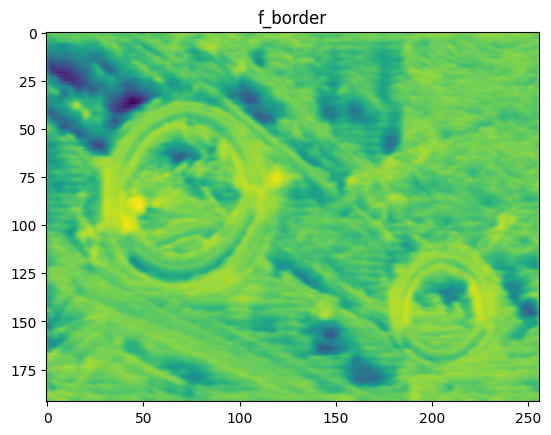

In [208]:
plt.imshow(preds['f_border'][0][0])
plt.title('f_border')

Text(0.5, 1.0, 'f_char')

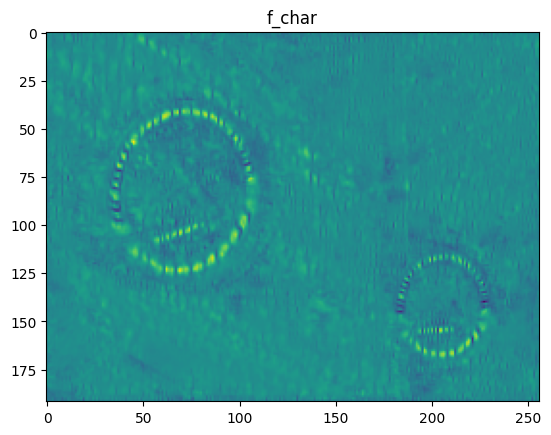

In [209]:
plt.imshow(preds['f_char'][0][36])
plt.title('f_char')

Text(0.5, 1.0, 'f_direction')

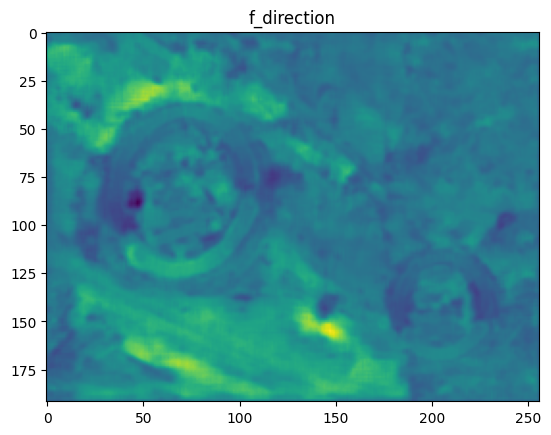

In [210]:
plt.imshow(preds['f_direction'][0][0])
plt.title('f_direction')

Text(0.5, 1.0, 'f_direction')

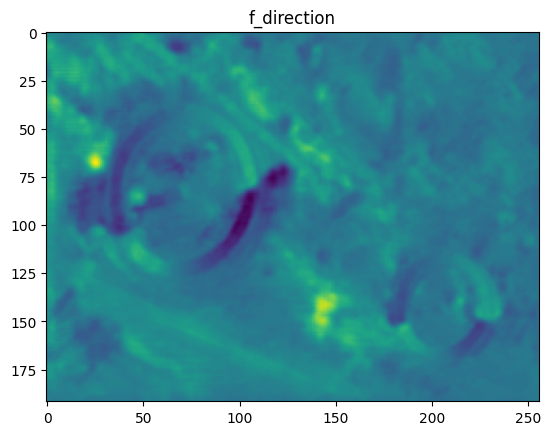

In [211]:
plt.imshow(preds['f_direction'][0][1])
plt.title('f_direction')

Text(0.5, 1.0, 'f_score')

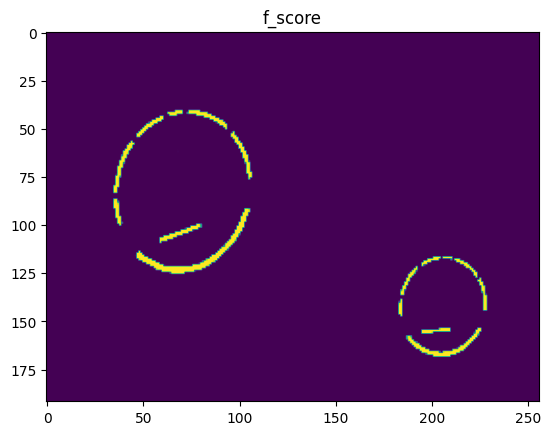

In [212]:
plt.imshow(preds['f_score'][0][0])
plt.title('f_score')

In [213]:
post_result = postprocess_op(preds,shape_list)
post_result

{'points': [array([[191.90626526, 111.07349396],
         [198.01278114, 111.01284301],
         [201.07185841, 110.2955898 ],
         [204.21459675, 109.58334434],
         [208.02948475, 108.89829135],
         [221.89195251, 106.79543304],
         [222.09931946, 125.19405365],
         [211.14001274, 127.10017765],
         [207.86161423, 127.36258554],
         [205.11820316, 127.94274116],
         [202.32663155, 128.79808927],
         [196.52044678, 131.20755005]]),
  array([[228.93002319, 105.08583832],
         [245.95866203, 107.89618027],
         [260.06131172, 110.5735302 ],
         [273.95234108, 114.89491606],
         [286.02702618, 121.26389623],
         [300.996521  , 129.67700195],
         [289.69656372, 147.61286926],
         [276.71899796, 139.82391047],
         [264.69931602, 133.59542298],
         [251.95016861, 129.99264836],
         [241.21632576, 127.30264115],
         [226.54769897, 124.83631897]]),
  array([[138.67243958, 146.71212769],
         [1

In [214]:
points = post_result['points']
strs = post_result['texts']

In [215]:
dt_boxes = filter_tag_det_res_only_clip(points,image.shape)
dt_boxes.shape

(15, 12, 2)

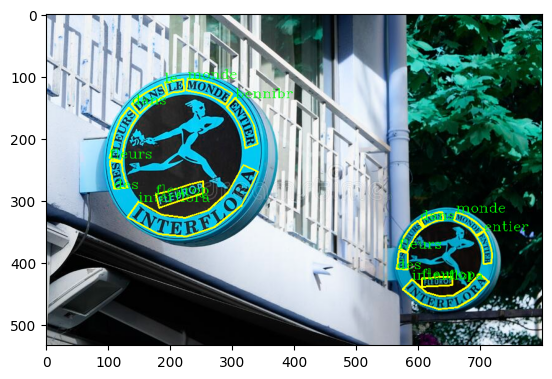

In [217]:
output = utility.draw_e2e_res(dt_boxes, strs,'../imgs/input.jpg')
plt.imshow(output)

# draw polygon mask

OCR

# chatGPTs code

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
img = cv2.imread("image.jpg")

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding to create a binary image
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Perform morphological operations to remove noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Detect the edges of the text
edges = cv2.Canny(opening, 100, 200)

# Find the lines in the image using Hough line detection
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=5)

# Find the angle of the text by taking the average of the angles of the lines
angle = 0
for line in lines:
    x1, y1, x2, y2 = line[0]
    angle += np.arctan2(y2 - y1, x2 - x1)
angle /= len(lines)

# Rotate the image to straighten the text
rows, cols = img.shape[:2]
M = cv2.getRotationMatrix2D((cols/2, rows/2), angle * 180 / np.pi, 1)
dst = cv2.warpAffine(img, M, (cols, rows))

# Show the result
# cv2.imshow("Straightened Text", dst)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(dst)

TypeError: 'NoneType' object is not iterable

# references

[Scene Text Image Super-Resolution for OCR](https://stackoverflow.com/questions/64808986/scene-text-image-super-resolution-for-ocr)

[OpenCV Morphological Operations](https://pyimagesearch.com/2021/04/28/opencv-morphological-operations/)

[pgnet openvino](https://aistudio.baidu.com/aistudio/projectdetail/5208774?channelType=0&channel=0)